# Job App Chain

> This langgraph application is build to get jobs online qualify them and manage a google sheet  
> This is designed to be used for a single user

## Imports and Config

In [3]:
import uuid
import os
from typing import Literal, TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from IPython.display import Image, display
from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt

load_dotenv()

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

## Graph State

In [7]:
class JobDescription(TypedDict):
    id: str
    position: str
    company: str
    location: str
    description: str
    url: str
    date_posted: str
    salary_range: str
    approved: bool = False # if the job is approved in inbox the next run will send to optimizer

class JobApplication(JobDescription):
    resume_path: str
    cover_letter_path: str
    applied: bool = False # if the job is applied to the next run will send to job_tracker

class JobAppState(TypedDict):
    # metadata
    last_execution_time: str
    run_log: list[str] # logs for this run to append to Logs

    # state flags
    is_locked: bool # is the sheet red(block edits) or green(allow edits) its a mutex lock

    # data buckets
    jobs_scraped: list[JobDescription] # jobs that have been scraped
    jobs_in_posting_inbox: list[JobDescription] # approved by ai jobs
    jobs_to_move_to_app_inbox: list[JobApplication] # approved and optimized job applications
    jobs_to_move_to_tracker: list[JobApplication] # applied jobs tab
    jobs_to_reject: list[JobDescription] # rejected tab jobs
    

## Node Functions

In [ ]:
# Looks at inboxes and moves jobs to proper list
def check_inbox_and_clean_node(state: JobAppState) -> JobAppState:
    """Checks the inbox and moves the job to tracker or reject"""
    return state

# jobspy and playwright to get job postings and remove duplicates
def scrape_jobs_node(state: JobAppState) -> JobAppState:
    """Scrapes jobs and cleans the data for LLM processing."""
    return state

# AGENT - this agent will grade how qualified I am for the job
# depending on grade the job will be moved to reject or added to the first inbox 
def sort_jobs_node(state: JobAppState) -> JobAppState:
    """sorts jobs by qualifications, experience, and other criteria"""
    return state

# takes the jobs from the 
def add_to_sheet_node(state: JobAppState) -> JobAppState:
    """Adds the job to the inbox sheet"""
    return state

def optimize_jobs_node(state: JobAppState) -> JobAppState:
    """Optimizes resumes and cover letters for each job"""
    return state

def reject_job_node(state: JobAppState) -> JobAppState:
    """Rejects the job, adds to reject sheet"""
    return state



## Build Graph

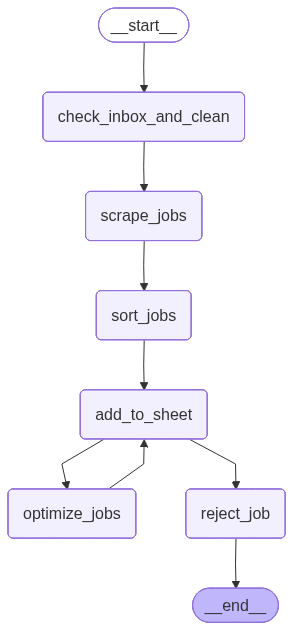

In [6]:
builder = StateGraph(JobAppState)

builder.add_node("check_inbox_and_clean", check_inbox_and_clean_node)
builder.add_node("scrape_jobs", scrape_jobs_node)
builder.add_node("sort_jobs", sort_jobs_node)
builder.add_node("add_to_sheet", add_to_sheet_node)
builder.add_node("optimize_jobs", optimize_jobs_node)
builder.add_node("reject_job", reject_job_node)

builder.add_edge(START, "check_inbox_and_clean")
builder.add_edge("check_inbox_and_clean", "scrape_jobs")
builder.add_edge("scrape_jobs", "sort_jobs")
builder.add_edge("sort_jobs", "add_to_sheet")
builder.add_edge("add_to_sheet", "optimize_jobs")
builder.add_edge("add_to_sheet", "reject_job")
builder.add_edge("reject_job", END)
builder.add_edge("optimize_jobs", "add_to_sheet")
builder.add_edge("add_to_sheet", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))